In [1]:
words = open("names.txt","r").read().split("\n")

In [2]:
b = {}
for word in words:
    # chs = ["<S>"] + list(word) + ["<E>"] # 始まりと終わりの目印を付け加える
    chs = ["."] + list(word) + ["."] # 始まりと終わりの目印を付け加える
    for ch1,ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 # {(文字,文字), その組み合わせが何回出てきたか} という辞書を作る

sorted(b.items(), key = lambda x: -x[1]) # [1]番目の要素をkeyとしてsortする 辞書(b)は並び替えられないので、items()を使ってリストのような形にする

chars = sorted(list(set("".join(words)))) # 全文字のリストを作る


In [3]:
stoi = {j:i+1 for i,j in enumerate(chars)} # "."を0番目に入れるためにi+1で一つずらす
stoi["."] = 0
itos = {i+1:j for i,j in enumerate(chars)}
itos[0] = "."


In [4]:
import torch # torch.Tensor(xs) # .tensorならint、.Tensorならfloat

N = torch.zeros((27,27), dtype=torch.int32) #全部の要素が0のテンソルを作る

In [5]:
for word in words:
    chs = ["."] + list(word) + ["."] # 始まりと終わりの目印を付け加える
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # emmaだったらch1に"e",chsに"m"が入り、stoi["e"]とstoi["m"]をix1とix2に代入する。
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1 # stoi["e"]=5,stoi["m"]=13だから、N[5,13]に+1する

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

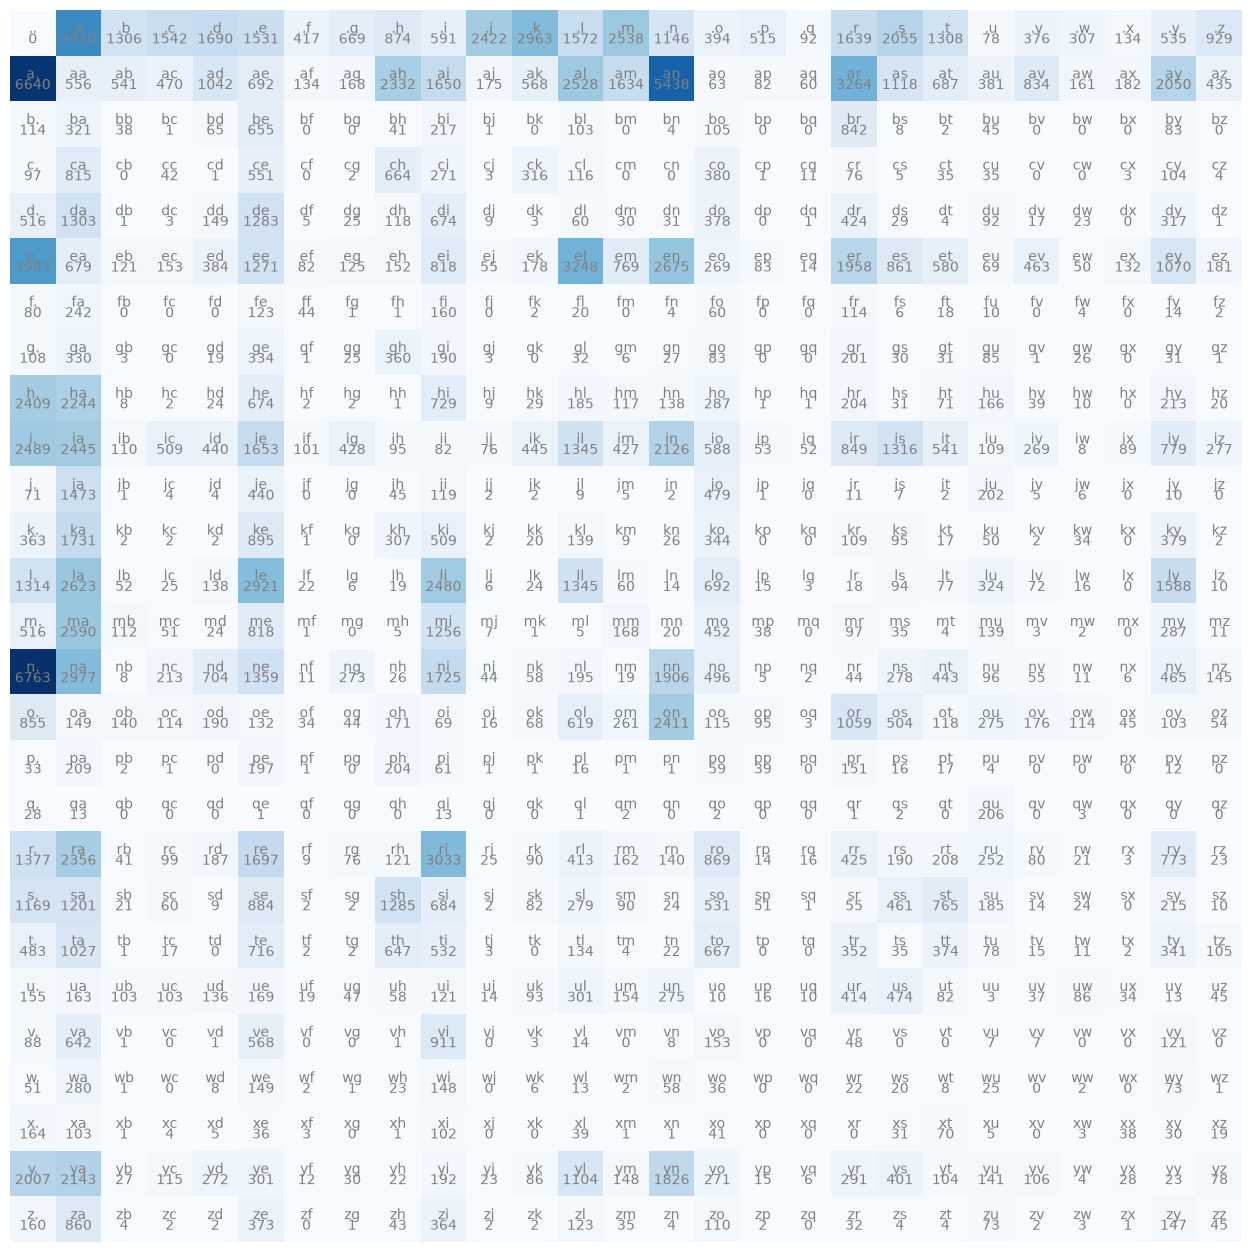

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

# 見やすいグラフを描画するためのコード　andrejがどっかから持ってきた
plt.figure(figsize = (16,16))
plt.imshow(N, cmap = "Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis("off")


In [7]:
P = (N+1).float() # N+1は平滑化。確率0のものがあると絶対に作られない文字列が出てきたときに損失が爆発する。
P = P / P.sum(1, keepdim=True) 
# tensorの.sum(dim,keepdim=False)ではdim次元目がなくなる方向に足し算, keepdim=Trueしたらtorch.Size([27, 1])みたいな感じで次元が残る
# [27,27]/[27,1]したら27個の値が横方向にコピーされる
# [[3,]
#  [2,]
#  [4,]]
# だったら
# [[3,3,3]
# [2,2,2]
# [4,4,4]]
# になるイメージ

In [8]:
g = torch.Generator().manual_seed(2147483647)
# torch.multinomial(input, num_samples, replacement=False, generator=None)はinputの確率分布からランダムに一つを選ぶ関数
# inputは確率分布, num_samplesは出力するサンプル数, replacementは重複出力okかどうか, generatorは乱数生成器

for i in range(10):
    ix = 0
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, 1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix ==0:
            break
    print("".join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [9]:
# lilelihood(尤度) : どれだけその文字列が発生するっぽいか。"emma"だったら単純に、(eが来る確率)×(その後にmが来る確率)×(その後にmが来る確率)×...を求める。
# ただし、掛け算をするとデータ数が多くなるほど指数的に尤度が変化してしまうため、対策としてlogを取る。log(a*b*c)=log(a)+log(b)+log(c)とできるので線形にしか増えない。
log_likelihood = 0
n = 0
for word in words:
# for word in ["andrejq"]:
    chs = ["."] + list(word) + ["."] # 始まりと終わりの目印を付け加える
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        prob = P[ix1][ix2]
        logprob = torch.log(prob)
        # print(ch1, ch2, prob, logprob)
        log_likelihood += logprob
        n += 1

print(log_likelihood)
nll = -log_likelihood
print(nll)
loss = nll/n
print(loss)


tensor(-559951.5625)
tensor(559951.5625)
tensor(2.4544)


In [10]:
xs = []
ys = []
for word in words:
    chs = ["."] + list(word) + ["."] # 始まりと終わりの目印を付け加える
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

In [11]:
# ix1を入れてix2が出てくるモデルを作りたい
# one-hot変換するためにtorch.tensor形式にする
x = torch.tensor(xs)
y = torch.tensor(ys)
num = x.nelement()
print("number of examples", num)

import torch.nn.functional as F
# One-hot変換
xenc = F.one_hot(x, num_classes=27).float()

# ランダムな重みW作製, requires_grad=Trueを渡すことで後からmicrogradの時のようにgradの計算ができるようになる。
W = torch.randn((27,27), requires_grad=True)

number of examples 228146


In [12]:
for i in range(100):
    # forward
    # 一層ニューラルネットワーク
    logits = xenc @ W
    # 確率として扱いたいから全部してexp()正の値にする
    counts = logits.exp()
    # そして合計で割る→softmaxと同じ処理
    probs = counts / counts.sum(dim=1, keepdim=True)
    loss = -probs[torch.arange(num),y].log().mean() + 0.01*(W**2).mean()
    # p = probs[torch.arange(num),y]
    # logp = torch.log(p)
    # log_likelihood += logp.sum()
    # loss = -log_likelihood / num
    # とも書ける
    # + (0.01*(W**2).mean())は過剰適合を避けるための正則化
    print(loss)

    # backward
    W.grad = None # gradをNone(0)にする
    loss.backward() # lossを小さくする方向(grad)を求める

    # update
    W.data += -50 * W.grad

tensor(3.7216, grad_fn=<AddBackward0>)
tensor(3.3910, grad_fn=<AddBackward0>)
tensor(3.1787, grad_fn=<AddBackward0>)
tensor(3.0345, grad_fn=<AddBackward0>)
tensor(2.9306, grad_fn=<AddBackward0>)
tensor(2.8542, grad_fn=<AddBackward0>)
tensor(2.7974, grad_fn=<AddBackward0>)
tensor(2.7546, grad_fn=<AddBackward0>)
tensor(2.7219, grad_fn=<AddBackward0>)
tensor(2.6962, grad_fn=<AddBackward0>)
tensor(2.6755, grad_fn=<AddBackward0>)
tensor(2.6583, grad_fn=<AddBackward0>)
tensor(2.6438, grad_fn=<AddBackward0>)
tensor(2.6313, grad_fn=<AddBackward0>)
tensor(2.6205, grad_fn=<AddBackward0>)
tensor(2.6110, grad_fn=<AddBackward0>)
tensor(2.6026, grad_fn=<AddBackward0>)
tensor(2.5951, grad_fn=<AddBackward0>)
tensor(2.5884, grad_fn=<AddBackward0>)
tensor(2.5824, grad_fn=<AddBackward0>)
tensor(2.5769, grad_fn=<AddBackward0>)
tensor(2.5719, grad_fn=<AddBackward0>)
tensor(2.5674, grad_fn=<AddBackward0>)
tensor(2.5633, grad_fn=<AddBackward0>)
tensor(2.5595, grad_fn=<AddBackward0>)
tensor(2.5559, grad_fn=<A

In [16]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    ix = 0
    out = []
    while True:
        x = torch.tensor([ix]) # [ix]って囲まないとxencが([27])になってしまう。囲むと([1,27])になる
        xenc = F.one_hot(x, num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(dim=1, keepdim=True)

        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix ==0:
            break
    print("".join(out))


cexze.
momasurailezityha.
konimittain.
llayn.
ka.
